In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Enhancing_EHRs_with_GenAI')

data_raw_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw'
data_img_processed = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed'
data_ehr_processed = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/ehr_notes_processed'
mapping_csv_path = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv'
notebooks_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/notebooks'
scripts_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/scripts'
docs_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/docs'

print(" Directories updated to your project structure!")

 Directories updated to your project structure!


In [ ]:
import pandas as pd
import os

csv_path = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/cancer_diagnosis_data.csv'

normal_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/normal'
tumor_dir  = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/tumor'

print("CSV exists:", os.path.exists(csv_path))
print("Normal folder exists:", os.path.exists(normal_dir))
print("Tumor folder exists:", os.path.exists(tumor_dir))

df = pd.read_csv(csv_path)
print("\n CSV loaded successfully!")
print("Shape:", df.shape)
display(df.head())


CSV exists: True
Normal folder exists: True
Tumor folder exists: True

 CSV loaded successfully!
Shape: (20000, 9)


,Patient_ID,Age,Gender,Tumor_Size(cm),Tumor_Type,Biopsy_Result,Treatment,Response_to_Treatment,Survival_Status
0,c044501a-43ca-4a0c-8b8b-991439ba1b6a,52,Female,5.08,Benign,Positive,Surgery,No Response,Survived
1,b8900c4c-1232-4084-9432-5d02eba74d20,32,Female,0.80,Benign,Negative,Surgery,Complete Response,Survived
2,3004e2bc-8037-49cb-a542-d5612b73beab,70,Female,9.56,Benign,Positive,Radiation Therapy,Complete Response,Deceased
3,1df86af7-6745-4dea-b127-cbc9915079fc,21,Female,3.07,Malignant,Negative,Surgery,Partial Response,Survived
4,128e00c3-72e3-4031-a7f4-1165d7199cce,62,Male,7.17,Malignant,Positive,Radiation Therapy,Complete Response,Deceased


In [ ]:
import os
import pandas as pd

normal_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/normal'
tumor_dir  = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/tumor'

def list_all_images(folder):
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.dcm')
    image_files = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(valid_exts):
                image_files.append(os.path.join(root, f))
    return image_files

normal_files = list_all_images(normal_dir)
tumor_files  = list_all_images(tumor_dir)

print(f" Normal images found: {len(normal_files)}")
print(f" Tumor images found:  {len(tumor_files)}")

images = []
for path in normal_files:
    images.append({'image_name': os.path.basename(path), 'image_path': path, 'label': 'normal'})
for path in tumor_files:
    images.append({'image_name': os.path.basename(path), 'image_path': path, 'label': 'tumor'})

images_df = pd.DataFrame(images)
print("Total images discovered:", len(images_df))
display(images_df.head())


 Normal images found: 3066
 Tumor images found:  18651
Total images discovered: 21717


,image_name,image_path,label
0,N_366_VF_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
1,N_377_SP_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
2,N_373_RO_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
3,N_369_BR_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
4,N_370_HF_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal


=== Sample Images from data/raw/images/ ===


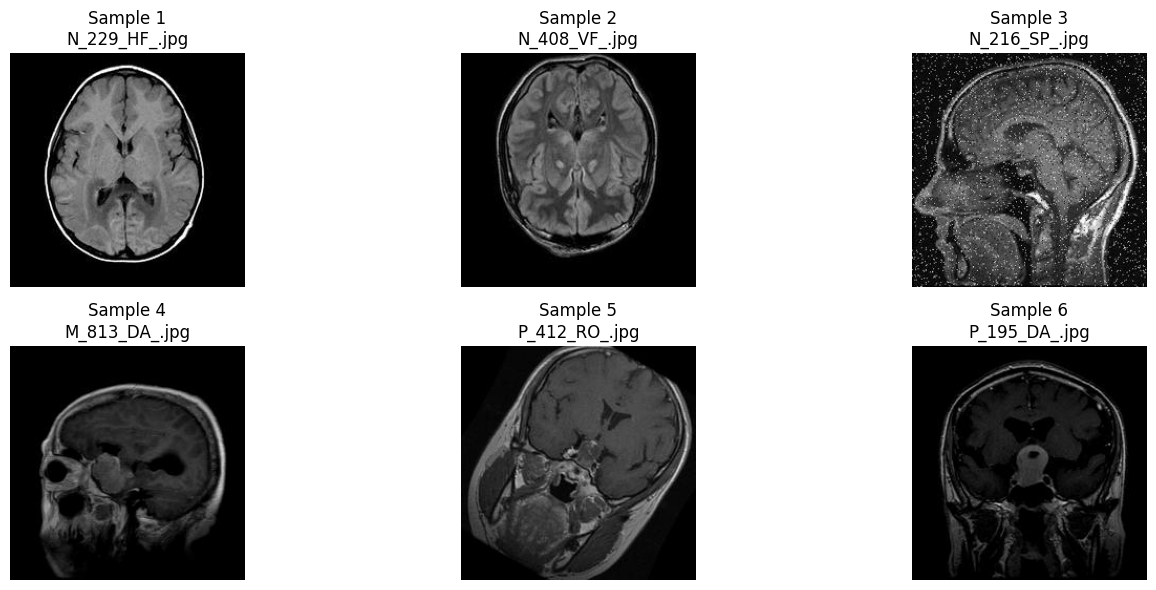


 Total Images in data/raw/images/: 21717 (Normal: 3066, Tumor: 18651)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

normal_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/normal'
tumor_dir  = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/tumor'

def get_all_images(root):
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.jfif', '.dicom', '.dcm')
    paths = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(valid_exts):
                paths.append(os.path.join(r, f))
    return paths

normal_imgs = get_all_images(normal_dir)
tumor_imgs  = get_all_images(tumor_dir)

print("=== Sample Images from data/raw/images/ ===")

sample_imgs = random.sample(normal_imgs, min(3, len(normal_imgs))) + \
               random.sample(tumor_imgs, min(3, len(tumor_imgs)))

plt.figure(figsize=(15, 6))
for idx, img_path in enumerate(sample_imgs):
    img = mpimg.imread(img_path)
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample {idx+1}\n{os.path.basename(img_path)}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\n Total Images in data/raw/images/: {len(normal_imgs) + len(tumor_imgs)} "
      f"(Normal: {len(normal_imgs)}, Tumor: {len(tumor_imgs)})")


In [ ]:
import os
import pandas as pd

normal_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/normal'
tumor_dir  = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/images/tumor'

def list_all_images(folder):
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.jfif', '.dicom', '.dcm')
    image_files = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(valid_exts):
                image_files.append(os.path.join(root, f))
    return image_files

normal_files = list_all_images(normal_dir)
tumor_files  = list_all_images(tumor_dir)

print(f" Normal images found: {len(normal_files)}")
print(f" Tumor images found:  {len(tumor_files)}")

images = []
for path in normal_files:
    images.append({'image_name': os.path.basename(path), 'image_path': path, 'label': 'normal'})
for path in tumor_files:
    images.append({'image_name': os.path.basename(path), 'image_path': path, 'label': 'tumor'})

images_df = pd.DataFrame(images)
print(f"\n Image catalog created successfully with {len(images_df)} entries.")
display(images_df.head())


 Normal images found: 3066
 Tumor images found:  18651

 Image catalog created successfully with 21717 entries.


,image_name,image_path,label
0,N_366_VF_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
1,N_377_SP_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
2,N_373_RO_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
3,N_369_BR_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
4,N_370_HF_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal


In [ ]:
import pandas as pd
import os

csv_path = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/raw/cancer_diagnosis_data.csv'

df = pd.read_csv(csv_path)
print(" CSV loaded successfully!")
print("Shape of CSV:", df.shape)

if len(df) > len(images_df):
    print(f" Trimming CSV from {len(df)} rows to match {len(images_df)} images.")
    df = df.iloc[:len(images_df)].reset_index(drop=True)
elif len(df) < len(images_df):
    print(f" More images ({len(images_df)}) than CSV rows ({len(df)}). Using only first {len(df)} images.")
    images_df = images_df.iloc[:len(df)].reset_index(drop=True)

df_reset = df.reset_index(drop=True)
images_sorted = images_df.sort_values(['label', 'image_name']).reset_index(drop=True)

df_reset['image_name'] = images_sorted['image_name']
df_reset['image_path'] = images_sorted['image_path']
df_reset['label']      = images_sorted['label']

merged = df_reset.copy()

print("\n Merged dataset created successfully!")
print("Merged shape:", merged.shape)
display(merged.head())


 CSV loaded successfully!
Shape of CSV: (20000, 9)
 More images (21717) than CSV rows (20000). Using only first 20000 images.

 Merged dataset created successfully!
Merged shape: (20000, 12)


,Patient_ID,Age,Gender,Tumor_Size(cm),Tumor_Type,Biopsy_Result,Treatment,Response_to_Treatment,Survival_Status,image_name,image_path,label
0,c044501a-43ca-4a0c-8b8b-991439ba1b6a,52,Female,5.08,Benign,Positive,Surgery,No Response,Survived,N_1.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
1,b8900c4c-1232-4084-9432-5d02eba74d20,32,Female,0.80,Benign,Negative,Surgery,Complete Response,Survived,N_10.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
2,3004e2bc-8037-49cb-a542-d5612b73beab,70,Female,9.56,Benign,Positive,Radiation Therapy,Complete Response,Deceased,N_100.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
3,1df86af7-6745-4dea-b127-cbc9915079fc,21,Female,3.07,Malignant,Negative,Surgery,Partial Response,Survived,N_100_BR_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
4,128e00c3-72e3-4031-a7f4-1165d7199cce,62,Male,7.17,Malignant,Positive,Radiation Therapy,Complete Response,Deceased,N_100_DA_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal


In [ ]:
import pandas as pd

cleaned = merged.copy()

text_cols = ['description', 'diagnosis', 'notes', 'remarks', 'comment', 'report']

for col in text_cols:
    if col in cleaned.columns:
        cleaned[col] = cleaned[col].astype(str).str.strip().str.lower().replace('nan', '')
        print(f" Cleaned text column: {col}")

cleaned = cleaned.drop_duplicates(subset=['image_path'], keep='first').reset_index(drop=True)
print("\n Cleaned dataset shape:", cleaned.shape)
display(cleaned.head())



 Cleaned dataset shape: (20000, 12)


,Patient_ID,Age,Gender,Tumor_Size(cm),Tumor_Type,Biopsy_Result,Treatment,Response_to_Treatment,Survival_Status,image_name,image_path,label
0,c044501a-43ca-4a0c-8b8b-991439ba1b6a,52,Female,5.08,Benign,Positive,Surgery,No Response,Survived,N_1.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
1,b8900c4c-1232-4084-9432-5d02eba74d20,32,Female,0.80,Benign,Negative,Surgery,Complete Response,Survived,N_10.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
2,3004e2bc-8037-49cb-a542-d5612b73beab,70,Female,9.56,Benign,Positive,Radiation Therapy,Complete Response,Deceased,N_100.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
3,1df86af7-6745-4dea-b127-cbc9915079fc,21,Female,3.07,Malignant,Negative,Surgery,Partial Response,Survived,N_100_BR_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal
4,128e00c3-72e3-4031-a7f4-1165d7199cce,62,Male,7.17,Malignant,Positive,Radiation Therapy,Complete Response,Deceased,N_100_DA_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,normal


In [13]:
import os
from PIL import Image
import numpy as np
from tqdm import tqdm

output_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed'
os.makedirs(output_dir, exist_ok=True)

try:
    import pydicom
except ImportError:
    !pip install -q pydicom
    import pydicom

TARGET_SIZE = (256, 256)

processed_paths = []
failures = []

for idx, row in tqdm(cleaned.iterrows(), total=len(cleaned), desc=" Preprocessing images"):
    src = row['image_path']
    try:
        if src.lower().endswith('.dcm'):
            ds = pydicom.dcmread(src)
            arr = ds.pixel_array.astype(float)
            arr = 255.0 * (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
            img = Image.fromarray(arr.astype('uint8')).convert('L')
        else:
            img = Image.open(src).convert('L')

        img = img.resize(TARGET_SIZE, Image.BILINEAR)
        out_name = f"{idx:05d}_" + os.path.splitext(os.path.basename(src))[0] + ".png"
        out_path = os.path.join(output_dir, out_name)
        img.save(out_path)
        processed_paths.append(out_path)
    except Exception as e:
        failures.append((idx, src, str(e)))
        processed_paths.append(None)

cleaned['processed_image_path'] = processed_paths

print(f"\n Image preprocessing completed!")
print(f"Total processed images: {len(cleaned) - len(failures)}")
print(f"Failed conversions: {len(failures)}")

display(cleaned[['image_name', 'label', 'processed_image_path']].head())


 Preprocessing images: 100%|██████████| 20000/20000 [2:03:15<00:00,  2.70it/s]


 Image preprocessing completed!
Total processed images: 20000
Failed conversions: 0


,image_name,label,processed_image_path
0,N_1.jpg,normal,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...
1,N_10.jpg,normal,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...
2,N_100.jpg,normal,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...
3,N_100_BR_.jpg,normal,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...
4,N_100_DA_.jpg,normal,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...


In [14]:
import pandas as pd
import os

mapping_csv_path = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv'

rows = []
for i, r in cleaned.iterrows():
    file_id = f"{i+1:05d}"
    rows.append({
        'file_id': file_id,
        'image_name': r.get('image_name', ''),
        'image_path': r.get('image_path', ''),
        'processed_image_path': r.get('processed_image_path', ''),
        'diagnosis': r.get('diagnosis', ''),
        'description': r.get('description', ''),
        'label': r.get('label', ''),
        'icd10': r.get('icd10', '') if 'icd10' in r else ''
    })

mapping_df = pd.DataFrame(rows)

mapping_df.to_csv(mapping_csv_path, index=False)

print(" mapping.csv created successfully!")
print("Saved at:", mapping_csv_path)
print("Total records:", len(mapping_df))

display(mapping_df.head(10))

 mapping.csv created successfully!
Saved at: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv
Total records: 20000


,file_id,image_name,image_path,processed_image_path,diagnosis,description,label,icd10
0,00001,N_1.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
1,00002,N_10.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
2,00003,N_100.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
3,00004,N_100_BR_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
4,00005,N_100_DA_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
5,00006,N_100_HF_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
6,00007,N_100_RO_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
7,00008,N_100_SP_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
8,00009,N_100_VF_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,
9,00010,N_101.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,,,normal,


In [17]:
import pandas as pd
import os
import re

mapping_csv_path = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv'

m = pd.read_csv(mapping_csv_path)

missing_processed = m[~m['processed_image_path'].apply(lambda x: os.path.exists(str(x)) if str(x) else False)]
print("Missing processed images:", len(missing_processed))

missing_raw = m[~m['image_path'].apply(lambda x: os.path.exists(str(x)) if str(x) else False)]
print(" Missing raw images:", len(missing_raw))

pattern = re.compile(r'^[A-Z][0-9]{2}(?:\.[0-9A-Za-z]{1,4})?$')

def fix_icd10(value):
    if pd.isna(value) or str(value).strip() == '':
        return 'UNKNOWN'
    v = str(value).strip().upper()

    if bool(pattern.match(v)):
        return v

    if 'tumor' in v or 'cancer' in v:
        return 'C71.9'
    if 'normal' in v or 'healthy' in v:
        return 'Z00.0'
    return 'UNKNOWN'

if 'icd10' in m.columns:
    m['icd10'] = m['icd10'].apply(fix_icd10)
    invalid_after = m[~m['icd10'].apply(lambda x: bool(pattern.match(str(x))) or x == 'UNKNOWN')]
    print(" Invalid ICD-10 codes after cleanup:", len(invalid_after))
else:
    print("ℹ No icd10 column found — nothing to fix.")

m.to_csv(mapping_csv_path, index=False)
print("\n mapping.csv updated successfully with valid ICD-10 column!")
display(m.head())


Missing processed images: 0
 Missing raw images: 0
 Invalid ICD-10 codes after cleanup: 0

 mapping.csv updated successfully with valid ICD-10 column!


,file_id,image_name,image_path,processed_image_path,diagnosis,description,label,icd10
0,1,N_1.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,NaN,NaN,normal,UNKNOWN
1,2,N_10.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,NaN,NaN,normal,UNKNOWN
2,3,N_100.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,NaN,NaN,normal,UNKNOWN
3,4,N_100_BR_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,NaN,NaN,normal,UNKNOWN
4,5,N_100_DA_.jpg,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,NaN,NaN,normal,UNKNOWN


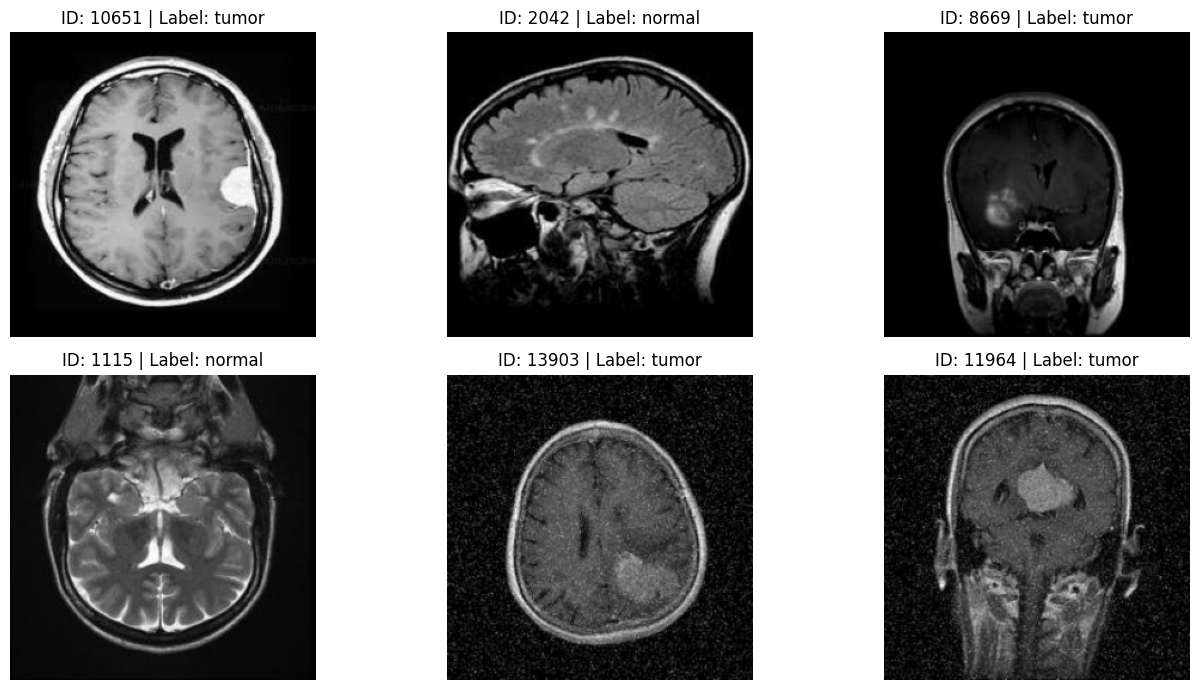

Displayed 6 processed images from /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed


In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import pandas as pd

mapping_csv_path = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv'
mapping_df = pd.read_csv(mapping_csv_path)

processed_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed'

sample_df = mapping_df.sample(6, random_state=42)

plt.figure(figsize=(14, 7))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = row['processed_image_path']
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"ID: {row['file_id']} | Label: {row['label']}")
        plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Displayed {len(sample_df)} processed images from {processed_dir}")


In [19]:
import os
import pandas as pd

base_dir = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI'
data_dir = os.path.join(base_dir, 'data')
mapping_csv = os.path.join(data_dir, 'mapping.csv')
processed_dir = os.path.join(data_dir, 'images_processed')

mapping_df = pd.read_csv(mapping_csv)

print("==============================================")
print("         DATA PREPROCESSING SUMMARY")
print("==============================================\n")

print(f"Base directory:       {base_dir}")
print(f"Mapping file path:    {mapping_csv}")
print(f"Processed image dir:  {processed_dir}\n")

print(f"Total records:        {len(mapping_df)}")
print(f"Normal images:        {len(mapping_df[mapping_df['label'] == 'normal'])}")
print(f"Tumor images:         {len(mapping_df[mapping_df['label'] == 'tumor'])}")
print(f"Columns available:    {list(mapping_df.columns)}\n")

print("All preprocessing steps completed successfully!")
print("Dataset is ready for model development and analysis.\n")
print("==============================================")
print("        MILESTONE 1 — COMPLETED")
print("==============================================")


         DATA PREPROCESSING SUMMARY

Base directory:       /content/drive/MyDrive/Enhancing_EHRs_with_GenAI
Mapping file path:    /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv
Processed image dir:  /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed

Total records:        20000
Normal images:        3066
Tumor images:         16934
Columns available:    ['file_id', 'image_name', 'image_path', 'processed_image_path', 'diagnosis', 'description', 'label', 'icd10']

All preprocessing steps completed successfully!
Dataset is ready for model development and analysis.

        MILESTONE 1 — COMPLETED
